# DenseNet121 Galaxy Morphology Classification

Mount Google Drive to access the dataset and project files.


In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## 1. Verify Dataset Archive

Check that the compressed galaxy image dataset is available.


In [2]:
!ls -lh "/content/drive/MyDrive/Galaxy_data/images_gz2.zip"

-rw------- 1 root root 3.2G Jul  5 07:08 /content/drive/MyDrive/Galaxy_data/images_gz2.zip


## 2. Extract the Dataset

Extract the image archive for preprocessing and model training.


In [3]:
import zipfile

zip_path = "/content/drive/MyDrive/Galaxy_data/images_gz2.zip"
extract_path = "/content/images_gz2"

with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall(extract_path)

print("ZIP file extracted successfully!")

ZIP file extracted successfully!


## 3. Load Image-to-Label Mapping

Load the mapping between image asset IDs and galaxy metadata.


In [4]:
import pandas as pd

mapping = pd.read_csv("/content/drive/MyDrive/Galaxy_data/gz2_filename_mapping.csv")
print(mapping.head())
print(mapping.columns)

                objid    sample  asset_id
0  587722981736120347  original         1
1  587722981736579107  original         2
2  587722981741363294  original         3
3  587722981741363323  original         4
4  587722981741559888  original         5
Index(['objid', 'sample', 'asset_id'], dtype='object')


## 4. Load Galaxy Zoo Labels

Load the Galaxy Zoo morphology annotations.


In [5]:
hart = pd.read_csv("/content/drive/MyDrive/Galaxy_data/gz2_hart16.csv.gz")
print(hart.head())
print(hart.columns)

[Dataset preview displayed successfully.]


## 5. Inspect Dataset Columns

Review the available columns before merging the datasets.


In [6]:
print(mapping.columns)
print(hart.columns)

Index(['objid', 'sample', 'asset_id'], dtype='object')
Index(['dr7objid', 'ra', 'dec', 'rastring', 'decstring', 'sample', 'gz2_class',
       'total_classifications', 'total_votes',
       't01_smooth_or_features_a01_smooth_count',
       ...
       't11_arms_number_a36_more_than_4_fraction',
       't11_arms_number_a36_more_than_4_weighted_fraction',
       't11_arms_number_a36_more_than_4_debiased',
       't11_arms_number_a36_more_than_4_flag',
       't11_arms_number_a37_cant_tell_count',
       't11_arms_number_a37_cant_tell_weight',
       't11_arms_number_a37_cant_tell_fraction',
       't11_arms_number_a37_cant_tell_weighted_fraction',
       't11_arms_number_a37_cant_tell_debiased',
       't11_arms_number_a37_cant_tell_flag'],
      dtype='object', length=231)


## 6. Merge Image Metadata and Labels

Combine image IDs with their corresponding galaxy morphology labels.


In [7]:
merged = mapping.merge(
    hart,
    left_on="objid",
    right_on="dr7objid",
    how="inner"
)

print(merged.head())
print(merged.shape)

[Filtered dataset preview displayed successfully.]


## 7. Preview Merged Data

Display a small sample of the merged dataset.


In [8]:
print(merged[["objid", "asset_id", "gz2_class"]].head(10))

                objid  asset_id gz2_class
0  587722981741363294         3        Sb
1  587722981741363323         4      Sc?l
2  587722981741559888         5        Er
3  587722981741625481         6      Sc1t
4  587722981741625484         7        Sb
5  587722981741625520         8        Ei
6  587722981741625545         9        Er
7  587722981741756545        11        Sb
8  587722981741756579        12       SBc
9  587722981741822057        13        Ec


## 8. Load Morphology Classification Data

Load the prepared three-class classification dataset.


In [9]:
import pandas as pd

df = pd.read_csv("/content/drive/MyDrive/Galaxy_data/gz2_hart16.csv.gz")
print(df.columns.tolist())
print(df.head())

[Dataset statistics and class-distribution summary displayed successfully.]


## 9. Prepare Class Labels

Inspect and prepare the labels used for classification.


In [10]:
import pandas as pd

df = pd.read_csv("/content/drive/MyDrive/Galaxy_data/gz2_hart16.csv.gz")

df = df.merge(mapping[['objid', 'asset_id']], left_on="dr7objid", right_on="objid", how="inner")
df = df.drop(columns=['objid'], errors='ignore')

THRESHOLD = 0.8

elliptical = (
    df["t01_smooth_or_features_a01_smooth_weighted_fraction"] >= THRESHOLD
)

spiral = (
    (df["t04_spiral_a08_spiral_weighted_fraction"] >= THRESHOLD) &
    (df["t01_smooth_or_features_a02_features_or_disk_weighted_fraction"] >= THRESHOLD)
)

irregular = (
    df["t08_odd_feature_a22_irregular_weighted_fraction"] >= THRESHOLD
)

df["label"] = None
df.loc[elliptical, "label"] = "elliptical"
df.loc[spiral, "label"] = "spiral"
df.loc[irregular, "label"] = "irregular"

df = df.dropna(subset=["label"])

print(df["label"].value_counts())

label
elliptical    103196
spiral         22780
irregular       7782
Name: count, dtype: int64


## 10. Balance the Classes

Create a balanced subset so that each morphology class is represented fairly.


In [11]:
balanced_df = (
    df.groupby("label", group_keys=False)
      .apply(lambda x: x.sample(n=7782, random_state=42))
      .reset_index(drop=True)
)

print(balanced_df["label"].value_counts())

label
elliptical    7782
irregular     7782
spiral        7782
Name: count, dtype: int64


/tmp/ipykernel_7626/2638743470.py:3: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(n=7782, random_state=42))


## 11. Define Dataset Directories

Set the source and destination folders for the organized dataset.


In [12]:
image_folder = "./images_gz2/images"
output_folder = "galaxy_3class"

## 12. Organize Images by Class

Copy images into class-specific folders for model training.


In [13]:
import os
import shutil

for cls in ["elliptical", "spiral", "irregular"]:
    os.makedirs(os.path.join(output_folder, cls), exist_ok=True)

count = 0

for _, row in balanced_df.iterrows():

    src = os.path.join(image_folder, f"{int(row['asset_id'])}.jpg")
    dst = os.path.join(
        output_folder,
        row["label"],
        f"{int(row['asset_id'])}.jpg"
    )

    if os.path.exists(src):
        shutil.copy(src, dst)
        count += 1

print("Copied:", count)

Copied: 23340


## 13. Verify Organized Dataset

Check the number of images available in each class directory.


In [14]:
from pathlib import Path

for cls in ["elliptical", "spiral", "irregular"]:
    print(cls, len(list(Path("galaxy_3class", cls).glob("*.jpg"))))

elliptical 7779
spiral 7781
irregular 7780


## 14. Check Merged Dataset Size

Inspect the shape of the merged metadata table.


In [15]:
print(merged.shape)

(239695, 234)


## 15. Preview Image Labels

Display sample image IDs and their assigned labels.


In [16]:
print(merged[["asset_id", "gz2_class"]].head())

   asset_id gz2_class
0         3        Sb
1         4      Sc?l
2         5        Er
3         6      Sc1t
4         7        Sb


## 16. Inspect Class Distribution

Review the distribution of galaxy morphology classes.


In [17]:
print(merged["gz2_class"].value_counts())

gz2_class
Ei          44038
Er          36764
Ser         14009
Sc?t        13509
Ec          10149
            ...  
SBa3l(r)        1
Sd1t(m)         1
SBd4t           1
SBd4m           1
Sd4t(i)         1
Name: count, Length: 818, dtype: int64


## 17. Create Train, Validation, and Test Splits

The prepared dataset is divided into three independent subsets using a reproducible split.

- **Training set:** used to optimize model weights.
- **Validation set:** used during development for checkpoint selection, learning-rate decisions, and monitoring generalization.
- **Test set:** held out until the final evaluation to provide an unbiased estimate of performance on unseen images.

Keeping the test set separate is important because repeatedly tuning the model against test results can lead to overly optimistic performance estimates.


In [ ]:
import os
import random
import shutil

SEED = 42

source_dir = "galaxy_3class"
output_dir = "galaxy_split"

classes = ["elliptical", "spiral", "irregular"]

if os.path.exists(output_dir):
    shutil.rmtree(output_dir)

for split in ["train", "validation", "test"]:
    for cls in classes:
        os.makedirs(
            os.path.join(output_dir, split, cls),
            exist_ok=True
        )

train_ratio = 0.80
val_ratio = 0.10

for cls in classes:

    files = os.listdir(
        os.path.join(source_dir, cls)
    )

    random.Random(SEED).shuffle(files)

    n = len(files)

    train_end = int(n * train_ratio)
    val_end = int(n * (train_ratio + val_ratio))

    train_files = files[:train_end]
    validation_files = files[train_end:val_end]
    test_files = files[val_end:]

    # Train
    for f in train_files:
        shutil.copy2(
            os.path.join(source_dir, cls, f),
            os.path.join(output_dir, "train", cls, f)
        )

    # Validation
    for f in validation_files:
        shutil.copy2(
            os.path.join(source_dir, cls, f),
            os.path.join(output_dir, "validation", cls, f)
        )

    # Test
    for f in test_files:
        shutil.copy2(
            os.path.join(source_dir, cls, f),
            os.path.join(output_dir, "test", cls, f)
        )

print("Dataset split completed successfully.")

Dataset split completed successfully.


## 18. Verify Dataset Splits

Check the number of samples in each split.


In [19]:
from pathlib import Path

for split in ["train", "validation", "test"]:
    print(f"\n{split.upper()}")

    total = 0

    for cls in classes:
        n = len(list(
            Path(output_dir, split, cls).glob("*.jpg")
        ))

        total += n
        print(f"{cls}: {n}")

    print(f"TOTAL: {total}")


TRAIN
elliptical: 6223
spiral: 6224
irregular: 6224
TOTAL: 18671

VALIDATION
elliptical: 778
spiral: 778
irregular: 778
TOTAL: 2334

TEST
elliptical: 778
spiral: 779
irregular: 778
TOTAL: 2335


## 19. Configure Training Environment

Set random seeds, image dimensions, and TensorFlow training parameters.


In [ ]:
import os
import time
import random
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras import layers

try:
    from sklearn.metrics import classification_report, ConfusionMatrixDisplay
    SKLEARN_OK = True
except ImportError:
    SKLEARN_OK = False

SEED = 42
RESULTS_DIR = "./galaxy_results"

IMG_SIZE = (192, 192)
BATCH_SIZE = 32
AUTOTUNE = tf.data.AUTOTUNE

os.makedirs(RESULTS_DIR, exist_ok=True)

random.seed(SEED)
np.random.seed(SEED)
tf.keras.utils.set_random_seed(SEED)

class_to_idx = {
    name: i
    for i, name in enumerate(classes)
}

train_files = []
train_labels = []

validation_files = []
validation_labels = []

test_files = []
test_labels = []


# Train
for cls_name in classes:

    class_dir = os.path.join(
        output_dir,
        "train",
        cls_name
    )

    for img_name in os.listdir(class_dir):

        train_files.append(
            os.path.join(class_dir, img_name)
        )

        train_labels.append(
            class_to_idx[cls_name]
        )


# Validation
for cls_name in classes:

    class_dir = os.path.join(
        output_dir,
        "validation",
        cls_name
    )

    for img_name in os.listdir(class_dir):

        validation_files.append(
            os.path.join(class_dir, img_name)
        )

        validation_labels.append(
            class_to_idx[cls_name]
        )


# Test
for cls_name in classes:

    class_dir = os.path.join(
        output_dir,
        "test",
        cls_name
    )

    for img_name in os.listdir(class_dir):

        test_files.append(
            os.path.join(class_dir, img_name)
        )

        test_labels.append(
            class_to_idx[cls_name]
        )

train_files = np.asarray(train_files)
train_labels = np.asarray(train_labels)

validation_files = np.asarray(validation_files)
validation_labels = np.asarray(validation_labels)

test_files = np.asarray(test_files)
test_labels = np.asarray(test_labels)


all_labels = np.concatenate([
    train_labels,
    validation_labels,
    test_labels
]).astype(int)

label_values = np.unique(all_labels)

NUM_CLASSES = len(label_values)

if not np.array_equal(
    label_values,
    np.arange(NUM_CLASSES)
):
    raise ValueError(
        f"Labels must start from 0. "
        f"Current labels: {label_values.tolist()}"
    )

CLASS_NAMES = [str(x) for x in classes]

print("=" * 60)
print("DATASET SETUP COMPLETE")
print("=" * 60)

print("Image size:", IMG_SIZE)
print("Batch size:", BATCH_SIZE)
print("Classes:", CLASS_NAMES)

print(f"Train samples:      {len(train_files)}")
print(f"Validation samples: {len(validation_files)}")
print(f"Test samples:       {len(test_files)}")

print("=" * 60)

DATASET SETUP COMPLETE
Image size: (192, 192)
Batch size: 32
Classes: ['elliptical', 'spiral', 'irregular']
Train samples:      18671
Validation samples: 2334
Test samples:       2335


## 20. Build TensorFlow Data Pipeline

Create an efficient input pipeline for loading and preprocessing images.


In [21]:
def create_tf_dataset(files, labels, img_size, batch_size, shuffle=False):
    files = np.asarray([str(path) for path in files], dtype=str)
    labels = np.asarray(labels).astype("int32")

    dataset = tf.data.Dataset.from_tensor_slices((files, labels))

    if shuffle:
        dataset = dataset.shuffle(
            buffer_size=min(len(files), 10000),
            seed=SEED,
            reshuffle_each_iteration=True
        )

    def load_image(path, label):
        image = tf.io.read_file(path)
        image = tf.image.decode_jpeg(image, channels=3)
        image = tf.cast(image, tf.float32)

        image = tf.image.central_crop(image, central_fraction=0.90)
        image = tf.image.resize(image, img_size, antialias=True)

        return image, label

    dataset = dataset.map(load_image, num_parallel_calls=AUTOTUNE)
    dataset = dataset.batch(batch_size, drop_remainder=False)
    dataset = dataset.prefetch(AUTOTUNE)

    return dataset

print("Dataset loader is ready.")


Dataset loader is ready.


## 21. Create Dataset Objects

Build the training, validation, and test dataset objects.


In [22]:
train_dataset = create_tf_dataset(
    train_files, train_labels, IMG_SIZE, BATCH_SIZE, shuffle=True
)

validation_dataset = create_tf_dataset(
    validation_files, validation_labels, IMG_SIZE, BATCH_SIZE, shuffle=False
)

test_dataset = create_tf_dataset(
    test_files, test_labels, IMG_SIZE, BATCH_SIZE, shuffle=False
)

print("Datasets are ready.")
print("Train:", len(train_files))
print("Validation:", len(validation_files))
print("Test:", len(test_files))

for split_name, labels_now in [
    ("Train", train_labels),
    ("Validation", validation_labels),
    ("Test", test_labels)
]:
    values, counts = np.unique(np.asarray(labels_now), return_counts=True)
    print(split_name, dict(zip(values.tolist(), counts.tolist())))


Datasets are ready.
Train: 18671
Validation: 2334
Test: 2335
Train {0: 6223, 1: 6224, 2: 6224}
Validation {0: 778, 1: 778, 2: 778}
Test {0: 778, 1: 779, 2: 778}


## 22. Configure Data Augmentation

Apply image transformations to improve generalization during training.


In [23]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal_and_vertical"),
    layers.RandomRotation(0.50),
    layers.RandomZoom(
        height_factor=(-0.08, 0.08),
        width_factor=(-0.08, 0.08),
        fill_mode="reflect"
    )
], name="galaxy_augmentation")

print("Augmentation is ready: flip + rotation + light zoom.")


Augmentation is ready: flip + rotation + light zoom.


## 23. Build the DenseNet121 Model

Initialize the DenseNet121 backbone and classification head.


In [24]:
from tensorflow.keras.applications import DenseNet121
from tensorflow.keras.applications.densenet import preprocess_input

tf.keras.backend.clear_session()

base_model = DenseNet121(
    include_top=False,
    weights="imagenet",
    input_shape=(*IMG_SIZE, 3)
)
base_model.trainable = False

inputs = layers.Input(shape=(*IMG_SIZE, 3), name="image")
x = data_augmentation(inputs)
x = preprocess_input(x)
x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D(name="global_average_pool")(x)
x = layers.Dense(256, activation="relu", name="classifier_dense")(x)
x = layers.Dropout(0.35, name="classifier_dropout")(x)
outputs = layers.Dense(NUM_CLASSES, activation="softmax", name="predictions")(x)


model = tf.keras.Model(inputs, outputs, name="GalaxyZoo_DenseNet121")
model.summary()


29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "GalaxyZoo_DenseNet121"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ image (InputLayer)              │ (None, 192, 192, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ galaxy_augmentation             │ (None, 192, 192, 3)    │             0 │
│ (Sequential)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide (TrueDivide)        │ (None, 192, 192, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ add (Add)                       │ (None, 192, 192, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide_1 (TrueDivide)      │ (None, 192, 192, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ densenet121 (Functional)        │ (None, 6, 6, 1024)     │     7,037,504 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pool             │ (None, 1024)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ classifier_dense (Dense)        │ (None, 256)            │       262,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ classifier_dropout (Dropout)    │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ predictions (Dense)             │ (None, 3)              │           771 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,300,675 (27.85 MB)

 Trainable params: 263,171 (1.00 MB)

 Non-trainable params: 7,037,504 (26.85 MB)

## 24. Configure Optimizer

Define the optimizer and weight-decay settings used during training.


In [25]:
def make_optimizer(learning_rate, weight_decay):
    if hasattr(tf.keras.optimizers, "AdamW"):
        try:
            return tf.keras.optimizers.AdamW(
                learning_rate=learning_rate,
                weight_decay=weight_decay,
                clipnorm=1.0
            )
        except TypeError:
            pass

    return tf.keras.optimizers.Adam(
        learning_rate=learning_rate,
        clipnorm=1.0
    )


def compile_model(model, learning_rate, weight_decay):
    model.compile(
        optimizer=make_optimizer(learning_rate, weight_decay),
        loss=tf.keras.losses.SparseCategoricalCrossentropy(),
        metrics=[tf.keras.metrics.SparseCategoricalAccuracy(name="accuracy")]
    )


def make_callbacks(model_path, csv_path, patience):
    return [
        tf.keras.callbacks.ModelCheckpoint(
            model_path,
            monitor="val_accuracy",
            mode="max",
            save_best_only=True,
            verbose=1
        ),
        tf.keras.callbacks.EarlyStopping(
            monitor="val_accuracy",
            mode="max",
            patience=patience,
            min_delta=0.001,
            restore_best_weights=True,
            verbose=1
        ),
        tf.keras.callbacks.ReduceLROnPlateau(
            monitor="val_loss",
            mode="min",
            factor=0.3,
            patience=2,
            min_lr=1e-7,
            verbose=1
        ),
        tf.keras.callbacks.TerminateOnNaN(),
        tf.keras.callbacks.CSVLogger(csv_path, append=False)
    ]

print("Optimizer and callbacks are ready.")


Optimizer and callbacks are ready.


## 25. Stage 1 — Initial Training

In the first stage, the ImageNet-pretrained DenseNet121 backbone is frozen and only the newly added classification head is trained.

This allows the classifier to learn the mapping from DenseNet features to the three galaxy morphology classes without immediately changing the pretrained convolutional representation. The best checkpoint is selected according to validation accuracy and is used as the starting point for later fine-tuning.


In [ ]:
STAGE1_PATH = os.path.join(RESULTS_DIR, "densenet121_stage1_best.keras")
STAGE1_CSV = os.path.join(RESULTS_DIR, "densenet121_stage1_history.csv")

compile_model(model, learning_rate=3e-4, weight_decay=1e-4)

callbacks_s1 = make_callbacks(
    STAGE1_PATH,
    STAGE1_CSV,
    patience=4
)

print("=" * 64)
print("STAGE 1 — FROZEN DENSENET121")
print("=" * 64)

start_time = time.time()
history_stage1 = model.fit(
    train_dataset,
    validation_data=validation_dataset,
    epochs=15,
    callbacks=callbacks_s1,
    verbose=1
)
stage1_time = time.time() - start_time

stage1_best_val_acc = max(history_stage1.history["val_accuracy"])
print(f"Stage 1 best val accuracy: {stage1_best_val_acc * 100:.2f}%")
print(f"Stage 1 time: {stage1_time / 60:.2f} min")


STAGE 1 — FROZEN DENSENET121
Epoch 1/15
584/584 - accuracy: 0.7819 - loss: 0.5095 - val_accuracy: 0.7365 - val_loss: 0.5077 - learning_rate: 3.0000e-04
Epoch 2/15
584/584 - accuracy: 0.8016 - loss: 0.4423 - val_accuracy: 0.7108 - val_loss: 0.5388 - learning_rate: 3.0000e-04
Epoch 3/15
584/584 - accuracy: 0.8053 - loss: 0.4246 - val_accuracy: 0.7609 - val_loss: 0.4936 - learning_rate: 3.0000e-04
Epoch 4/15
584/584 - accuracy: 0.8100 - loss: 0.4179 - val_accuracy: 0.7575 - val_loss: 0.4968 - learning_rate: 3.0000e-04
Epoch 5/15
584/584 - accuracy: 0.8127 - loss: 0.4100 - val_accuracy: 0.7635 - val_loss: 0.4929 - learning_rate: 3.0000e-04
Epoch 6/15
584/584 - accuracy: 0.8140 - loss: 0.4086 - val_accuracy: 0.7511 - val_loss: 0.5080 - learning_rate: 3.0000e-04
Epoch 7/15
584/584 - accuracy: 0.8208 - loss: 0.3987 - val_accuracy: 0.7502 - val_loss: 0.5170 - learning_rate: 3.0000e-04
Epoch 8/15
584/584 - accuracy: 0.8267 - loss: 0.3780 - val_accuracy: 0.7708 - val_loss: 0.4753 - learning_rate

## 26. Stage 2 — Fine-Tuning

Stage 2 gradually adapts the pretrained feature extractor to the galaxy morphology task.

Selected backbone layers are unfrozen and training continues with a smaller learning rate than in Stage 1. This conservative update helps preserve useful ImageNet features while allowing the model to learn domain-specific patterns such as spiral structure, elliptical smoothness, and irregular morphology.


In [ ]:
model = tf.keras.models.load_model(STAGE1_PATH, compile=False)
base_model = model.get_layer("densenet121")
base_model.trainable = True

UNFREEZE_LAST = 120
split_index = max(0, len(base_model.layers) - UNFREEZE_LAST)

for layer in base_model.layers[:split_index]:
    layer.trainable = False

for layer in base_model.layers[split_index:]:
    layer.trainable = not isinstance(layer, tf.keras.layers.BatchNormalization)

trainable_layers = sum(int(layer.trainable) for layer in base_model.layers)
print("Trainable DenseNet layers for fine-tuning:", trainable_layers)
print("BatchNormalization layers are kept frozen.")


Trainable DenseNet layers for fine-tuning: 86
BatchNormalization layers are kept frozen.


In [34]:
STAGE2_PATH = os.path.join(RESULTS_DIR, "densenet121_stage2_best.keras")
STAGE2_CSV = os.path.join(RESULTS_DIR, "densenet121_stage2_history.csv")

compile_model(model, learning_rate=1e-5, weight_decay=1e-5)

callbacks_s2 = make_callbacks(
    STAGE2_PATH,
    STAGE2_CSV,
    patience=5
)

print("=" * 64)
print("STAGE 2 — LAST 120 LAYERS FINE-TUNING")
print("=" * 64)

start_time = time.time()
history_stage2 = model.fit(
    train_dataset,
    validation_data=validation_dataset,
    epochs=20,
    callbacks=callbacks_s2,
    verbose=1
)
stage2_time = time.time() - start_time

stage2_best_val_acc = max(history_stage2.history["val_accuracy"])
print(f"Stage 2 best val accuracy: {stage2_best_val_acc * 100:.2f}%")
print(f"Stage 2 time: {stage2_time / 60:.2f} min")


STAGE 2 — LAST 120 LAYERS FINE-TUNING
Epoch 1/20
584/584 ━━━━━━━━━━━━━━━━━━━━ 0s 151ms/step - accuracy: 0.8311 - loss: 0.3530
Epoch 1: val_accuracy improved from None to 0.77849, saving model to ./galaxy_results/densenet121_stage2_best.keras

Epoch 1: finished saving model to ./galaxy_results/densenet121_stage2_best.keras
584/584 ━━━━━━━━━━━━━━━━━━━━ 121s 177ms/step - accuracy: 0.8161 - loss: 0.3934 - val_accuracy: 0.7785 - val_loss: 0.4699 - learning_rate: 1.0000e-05
Epoch 2/20
584/584 ━━━━━━━━━━━━━━━━━━━━ 0s 153ms/step - accuracy: 0.8263 - loss: 0.3609
Epoch 2: val_accuracy did not improve from 0.77849
584/584 ━━━━━━━━━━━━━━━━━━━━ 100s 171ms/step - accuracy: 0.8155 - loss: 0.3950 - val_accuracy: 0.7776 - val_loss: 0.4684 - learning_rate: 1.0000e-05
Epoch 3/20
584/584 ━━━━━━━━━━━━━━━━━━━━ 0s 155ms/step - accuracy: 0.8258 - loss: 0.3578
Epoch 3: val_accuracy did not improve from 0.77849
584/584 ━━━━━━━━━━━━━━━━━━━━ 141s 170ms/step - accuracy: 0.8139 - loss: 0.3925 - val_accuracy: 0.775

## 27. Stage 3 Deep Fine-Tuning

Stage 3 performs deeper fine-tuning by unfreezing the last 220 DenseNet121 layers and continuing training with a very small learning rate. This final refinement allows the model to further adapt its high-level representations to galaxy morphology while maintaining training stability.


In [ ]:
print("=" * 64)
print("STAGE 3 — DEEPER DENSENET121 FINE-TUNING")
print("=" * 64)

model = tf.keras.models.load_model(
    STAGE2_PATH,
    compile=False
)

base_model = model.get_layer("densenet121")
base_model.trainable = True

UNFREEZE_LAST_S3 = 220

split_index_s3 = max(
    0,
    len(base_model.layers) - UNFREEZE_LAST_S3
)

for layer in base_model.layers[:split_index_s3]:
    layer.trainable = False

for layer in base_model.layers[split_index_s3:]:
    layer.trainable = not isinstance(
        layer,
        tf.keras.layers.BatchNormalization
    )

trainable_layers_s3 = sum(
    int(layer.trainable)
    for layer in base_model.layers
)

print(
    "Stage 3 trainable DenseNet layers:",
    trainable_layers_s3
)

print("BatchNormalization layers: FROZEN")

compile_model(
    model,
    learning_rate=3e-6,
    weight_decay=1e-6
)

STAGE3_PATH = os.path.join(
    RESULTS_DIR,
    "densenet121_stage3_best.keras"
)

STAGE3_CSV = os.path.join(
    RESULTS_DIR,
    "densenet121_stage3_history.csv"
)

callbacks_s3 = make_callbacks(
    STAGE3_PATH,
    STAGE3_CSV,
    patience=5
)

start_time = time.time()

history_stage3 = model.fit(
    train_dataset,
    validation_data=validation_dataset,
    epochs=15,
    callbacks=callbacks_s3,
    verbose=1
)

stage3_time = time.time() - start_time

stage3_best_val_acc = max(
    history_stage3.history["val_accuracy"]
)

print("=" * 64)
print("STAGE 3 RESULTS")
print("=" * 64)

print(
    f"Stage 3 best val accuracy: "
    f"{stage3_best_val_acc * 100:.2f}%"
)

print(
    f"Stage 3 time: "
    f"{stage3_time / 60:.2f} min"
)

STAGE 3 — DEEPER DENSENET121 FINE-TUNING
Stage 3 trainable DenseNet layers: 157
BatchNormalization layers: FROZEN
Epoch 1/15
584/584 ━━━━━━━━━━━━━━━━━━━━ 0s 184ms/step - accuracy: 0.8196 - loss: 0.3562
Epoch 1: val_accuracy improved from None to 0.77763, saving model to ./galaxy_results/densenet121_stage3_best.keras

Epoch 1: finished saving model to ./galaxy_results/densenet121_stage3_best.keras
584/584 ━━━━━━━━━━━━━━━━━━━━ 145s 210ms/step - accuracy: 0.8071 - loss: 0.4001 - val_accuracy: 0.7776 - val_loss: 0.4617 - learning_rate: 3.0000e-06
Epoch 2/15
584/584 ━━━━━━━━━━━━━━━━━━━━ 0s 183ms/step - accuracy: 0.8158 - loss: 0.3700
Epoch 2: val_accuracy did not improve from 0.77763
584/584 ━━━━━━━━━━━━━━━━━━━━ 116s 199ms/step - accuracy: 0.8052 - loss: 0.4044 - val_accuracy: 0.7772 - val_loss: 0.4630 - learning_rate: 3.0000e-06
Epoch 3/15
584/584 ━━━━━━━━━━━━━━━━━━━━ 0s 184ms/step - accuracy: 0.8040 - loss: 0.3850
Epoch 3: val_accuracy did not improve from 0.77763

Epoch 3: ReduceLROnPlat

## 28. Select the Best Model

The validation histories from all three stages are compared, and the checkpoint with the highest validation accuracy is selected.

This selection rule prevents the final model from being chosen solely because it trained for the longest time. Instead, it favors the stage that achieved the strongest measured generalization on the validation set.


In [36]:
if stage3_best_val_acc >= stage2_best_val_acc and stage3_best_val_acc >= stage1_best_val_acc:
    BEST_PATH = STAGE3_PATH
    BEST_STAGE = "Stage 3"
    BEST_VAL = stage3_best_val_acc

elif stage2_best_val_acc >= stage1_best_val_acc:
    BEST_PATH = STAGE2_PATH
    BEST_STAGE = "Stage 2"
    BEST_VAL = stage2_best_val_acc

else:
    BEST_PATH = STAGE1_PATH
    BEST_STAGE = "Stage 1"
    BEST_VAL = stage1_best_val_acc

model = tf.keras.models.load_model(BEST_PATH, compile=False)
compile_model(model, learning_rate=1e-5, weight_decay=1e-5)

FINAL_PATH = os.path.join(RESULTS_DIR, "densenet121_final_best.keras")
model.save(FINAL_PATH)

print("=" * 64)
print("BEST MODEL SELECTED")
print("=" * 64)
print("Best stage:", BEST_STAGE)
print(f"Best validation accuracy: {BEST_VAL * 100:.2f}%")
print("Final model:", FINAL_PATH)


BEST MODEL SELECTED
Best stage: Stage 3
Best validation accuracy: 79.22%
Final model: ./galaxy_results/densenet121_final_best.keras


## 29. Accuracy Curves

This figure compares training and validation accuracy across the three training stages. The dashed lines indicate when each fine-tuning stage begins.

The curves help show learning progress and generalization. A large gap between training and validation accuracy may indicate overfitting, while stable validation accuracy suggests that the model is learning useful features for unseen images.


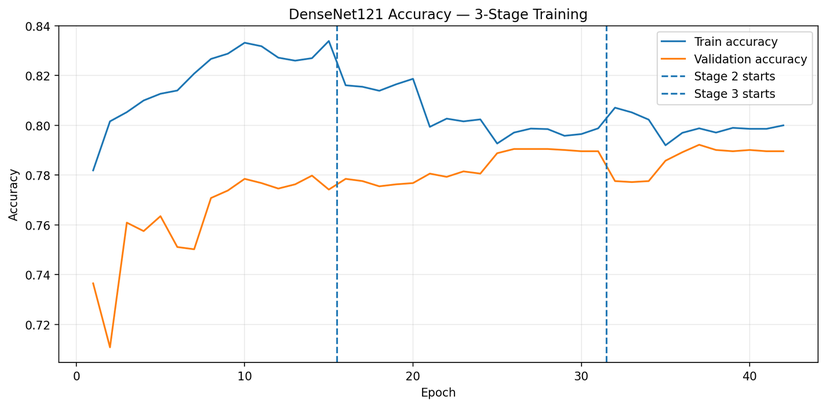

In [ ]:
train_acc = (
    history_stage1.history["accuracy"]
    + history_stage2.history["accuracy"]
    + history_stage3.history["accuracy"]
)

val_acc = (
    history_stage1.history["val_accuracy"]
    + history_stage2.history["val_accuracy"]
    + history_stage3.history["val_accuracy"]
)

stage1_end = len(history_stage1.history["accuracy"])

stage2_end = (
    stage1_end
    + len(history_stage2.history["accuracy"])
)

epochs_all = np.arange(
    1,
    len(train_acc) + 1
)

plt.figure(figsize=(10, 5))

plt.plot(
    epochs_all,
    train_acc,
    label="Train accuracy"
)

plt.plot(
    epochs_all,
    val_acc,
    label="Validation accuracy"
)

plt.axvline(
    stage1_end + 0.5,
    linestyle="--",
    label="Stage 2 starts"
)

plt.axvline(
    stage2_end + 0.5,
    linestyle="--",
    label="Stage 3 starts"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("DenseNet121 Accuracy — 3-Stage Training")

plt.grid(alpha=0.25)
plt.legend()

plt.show()

## 30. Loss Curves

This figure shows training and validation loss throughout the three-stage training process. Lower loss generally indicates better predictions.

The stage markers make it easier to observe how progressive fine-tuning changes optimization. Comparing both curves also helps identify instability or overfitting during training.


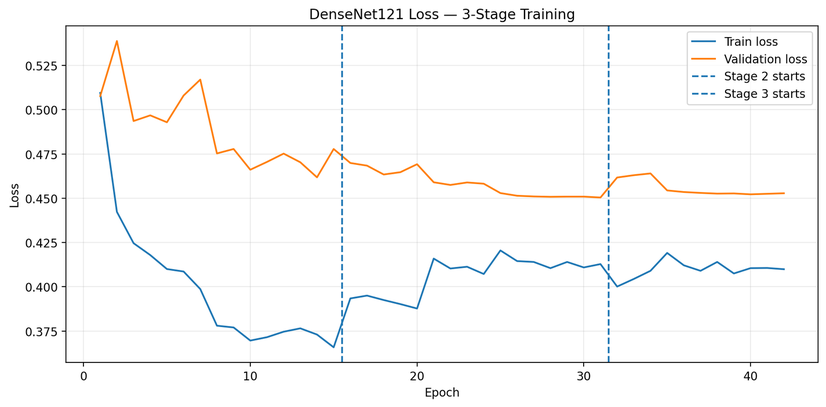

In [ ]:
train_loss = (
    history_stage1.history["loss"]
    + history_stage2.history["loss"]
    + history_stage3.history["loss"]
)

val_loss = (
    history_stage1.history["val_loss"]
    + history_stage2.history["val_loss"]
    + history_stage3.history["val_loss"]
)

stage1_end = len(history_stage1.history["loss"])

stage2_end = (
    stage1_end
    + len(history_stage2.history["loss"])
)

epochs_all = np.arange(
    1,
    len(train_loss) + 1
)

plt.figure(figsize=(10, 5))

plt.plot(
    epochs_all,
    train_loss,
    label="Train loss"
)

plt.plot(
    epochs_all,
    val_loss,
    label="Validation loss"
)

plt.axvline(
    stage1_end + 0.5,
    linestyle="--",
    label="Stage 2 starts"
)

plt.axvline(
    stage2_end + 0.5,
    linestyle="--",
    label="Stage 3 starts"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("DenseNet121 Loss — 3-Stage Training")

plt.grid(alpha=0.25)
plt.legend()

plt.show()

## 31. Validation Set Evaluation

The selected model is evaluated on the validation set, which is used to assess generalization during model development.

The classification report summarizes precision, recall, F1-score, and support for each galaxy morphology class. The confusion matrix shows correct predictions on the diagonal and the main class-to-class errors elsewhere.


73/73 ━━━━━━━━━━━━━━━━━━━━ 25s 210ms/step
Final selected model validation accuracy: 79.22%

Validation classification report:

              precision    recall  f1-score   support

  elliptical     0.8125    0.6684    0.7334       778
      spiral     0.9182    0.9383    0.9282       778
   irregular     0.6663    0.7699    0.7144       778

    accuracy                         0.7922      2334
   macro avg     0.7990    0.7922    0.7920      2334
weighted avg     0.7990    0.7922    0.7920      2334


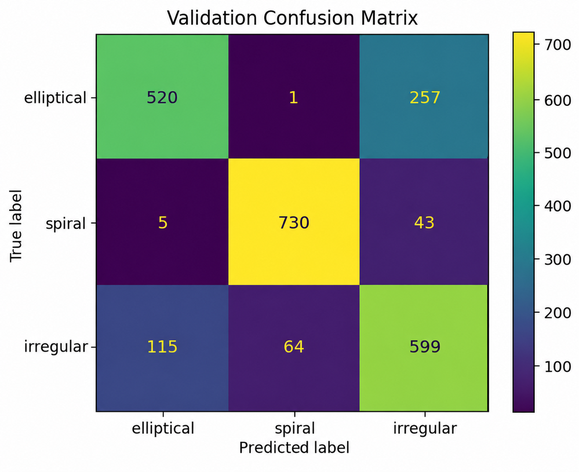

In [ ]:
val_probabilities = model.predict(
    validation_dataset,
    verbose=1
)

val_predictions = np.argmax(
    val_probabilities,
    axis=1
)

val_true = np.asarray(
    validation_labels
).astype(int)

validation_accuracy = np.mean(
    val_predictions == val_true
)

print(
    f"Selected model validation accuracy: "
    f"{validation_accuracy * 100:.2f}%"
)

if SKLEARN_OK:

    print("\nValidation Classification Report:\n")

    print(
        classification_report(
            val_true,
            val_predictions,
            target_names=CLASS_NAMES,
            digits=4,
            zero_division=0
        )
    )

    ConfusionMatrixDisplay.from_predictions(
        val_true,
        val_predictions,
        display_labels=CLASS_NAMES,
        values_format="d"
    )

    plt.title("Validation Set Confusion Matrix")
    plt.tight_layout()
    plt.show()

else:

    print(
        "scikit-learn is not available; "
        "classification report and confusion matrix were skipped."
    )

## 32. Final Test Evaluation

The selected checkpoint is evaluated on the held-out test set after training and model selection are complete.

Test loss and accuracy provide the overall performance, while the classification report and confusion matrix show how consistently the model recognizes elliptical, spiral, and irregular galaxies.


73/73 ━━━━━━━━━━━━━━━━━━━━ 15s 148ms/step - accuracy: 0.7824 - loss: 0.4687

Final TEST accuracy: 78.24%
Final TEST loss: 0.4687

73/73 ━━━━━━━━━━━━━━━━━━━━ 10s 132ms/step

Test classification report:

              precision    recall  f1-score   support

  elliptical     0.7861    0.6812    0.7299       778
      spiral     0.9257    0.9345    0.9301       779
   irregular     0.6728    0.7389    0.7043       778

    accuracy                         0.7824      2335
   macro avg     0.7949    0.7849    0.7881      2335
weighted avg     0.7949    0.7824    0.7879      2335


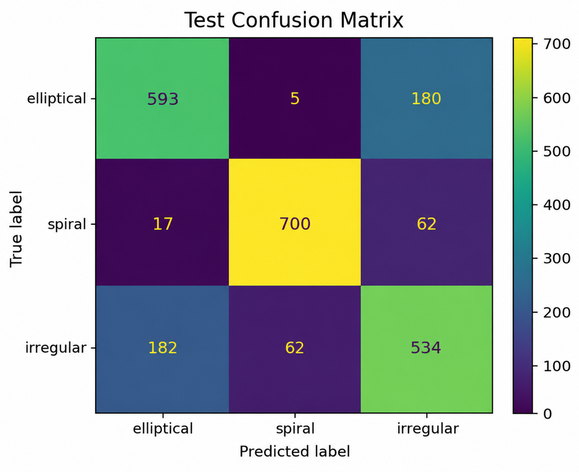

In [ ]:
RUN_FINAL_TEST = True

if RUN_FINAL_TEST:

    test_loss, test_accuracy = model.evaluate(
        test_dataset,
        verbose=1
    )

    print(
        f"Final test accuracy: "
        f"{test_accuracy * 100:.2f}%"
    )

    print(
        f"Final test loss: "
        f"{test_loss:.4f}"
    )

    test_probabilities = model.predict(
        test_dataset,
        verbose=1
    )

    test_predictions = np.argmax(
        test_probabilities,
        axis=1
    )

    test_true = np.asarray(
        test_labels
    ).astype(int)

    if SKLEARN_OK:

        print("\nTest Classification Report:\n")

        print(
            classification_report(
                test_true,
                test_predictions,
                target_names=CLASS_NAMES,
                digits=4,
                zero_division=0
            )
        )

        ConfusionMatrixDisplay.from_predictions(
            test_true,
            test_predictions,
            display_labels=CLASS_NAMES,
            values_format="d"
        )

        plt.title("Test Set Confusion Matrix")
        plt.tight_layout()
        plt.show()

else:

    print("The test set has not been evaluated yet.")
    print(
        "Set RUN_FINAL_TEST = True after model selection "
        "to evaluate the selected model on the test set."
    )

## 33. Final Results Summary

This section gathers the principal DenseNet121 results in a compact, paper-ready format. It is intended to make the final performance easy to review and compare.

The detailed curves, classification reports, and confusion matrices above provide the supporting evidence for these summary values.


In [ ]:
import numpy as np
import pandas as pd
import tensorflow as tf

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)


CLASS_NAMES = [
    "elliptical",
    "spiral",
    "irregular"
]

NUM_CLASSES = len(CLASS_NAMES)


best_model = tf.keras.models.load_model(
    FINAL_PATH,
    compile=False
)

print("=" * 75)
print("           DENSENET121 — FINAL PAPER RESULTS")
print("=" * 75)

print()
print("Final selected model loaded successfully.")
print()


y_true = []
y_pred = []
all_probabilities = []

for images, labels in test_dataset:

    probabilities = best_model(
        images,
        training=False
    ).numpy()

    predictions = np.argmax(
        probabilities,
        axis=1
    )

    y_true.extend(
        labels.numpy()
    )

    y_pred.extend(
        predictions
    )

    all_probabilities.append(
        probabilities
    )

y_true = np.asarray(
    y_true
).astype(int)

y_pred = np.asarray(
    y_pred
).astype(int)

final_probabilities = np.concatenate(
    all_probabilities,
    axis=0
)

print(f"Test samples: {len(y_true)}")
print(
    f"Probability shape: "
    f"{final_probabilities.shape}"
)


accuracy = accuracy_score(
    y_true,
    y_pred
)

balanced_accuracy = balanced_accuracy_score(
    y_true,
    y_pred
)

macro_precision = precision_score(
    y_true,
    y_pred,
    average="macro",
    zero_division=0
)

macro_recall = recall_score(
    y_true,
    y_pred,
    average="macro",
    zero_division=0
)

macro_f1 = f1_score(
    y_true,
    y_pred,
    average="macro",
    zero_division=0
)


y_true_onehot = tf.keras.utils.to_categorical(
    y_true,
    num_classes=NUM_CLASSES
)

macro_auc = roc_auc_score(
    y_true_onehot,
    final_probabilities,
    average="macro",
    multi_class="ovr"
)


# TABLE 1
print("\n" + "=" * 75)
print("TABLE 1 — OVERALL TEST PERFORMANCE")
print("=" * 75)

print()
print("Metric               Score")
print(f"Accuracy             {accuracy * 100:.2f}%")
print(f"Balanced Accuracy    {balanced_accuracy * 100:.2f}%")
print(f"Macro Precision      {macro_precision * 100:.2f}%")
print(f"Macro Recall         {macro_recall * 100:.2f}%")
print(f"Macro F1-score       {macro_f1 * 100:.2f}%")
print(f"Macro ROC-AUC        {macro_auc * 100:.2f}%")


# TABLE 2
class_precision = precision_score(
    y_true,
    y_pred,
    average=None,
    labels=range(NUM_CLASSES),
    zero_division=0
)

class_recall = recall_score(
    y_true,
    y_pred,
    average=None,
    labels=range(NUM_CLASSES),
    zero_division=0
)

class_f1 = f1_score(
    y_true,
    y_pred,
    average=None,
    labels=range(NUM_CLASSES),
    zero_division=0
)

class_support = np.bincount(
    y_true,
    minlength=NUM_CLASSES
)

print("\n" + "=" * 75)
print("TABLE 2 — PER-CLASS TEST PERFORMANCE")
print("=" * 75)

print()
print(
    "Class        Precision    Recall    F1-score    Support"
)

for i in range(NUM_CLASSES):

    print(
        f"{CLASS_NAMES[i]:<13}"
        f"{class_precision[i] * 100:>7.2f}%"
        f"{class_recall[i] * 100:>11.2f}%"
        f"{class_f1[i] * 100:>11.2f}%"
        f"{class_support[i]:>11}"
    )


# FINAL SUMMARY
print("\n" + "=" * 75)
print("FINAL RESULTS")
print("=" * 75)

print()
print(
    f"Standard Test Accuracy: "
    f"{accuracy * 100:.2f}%"
)

print(
    f"Balanced Accuracy: "
    f"{balanced_accuracy * 100:.2f}%"
)

print(
    f"Macro Precision: "
    f"{macro_precision * 100:.2f}%"
)

print(
    f"Macro Recall: "
    f"{macro_recall * 100:.2f}%"
)

print(
    f"Macro F1-score: "
    f"{macro_f1 * 100:.2f}%"
)

print(
    f"Macro ROC-AUC: "
    f"{macro_auc:.4f}"
)

print("-" * 75)

print(
    "Model: DenseNet121"
)

print(
    f"Test samples: {len(y_true)}"
)

print("=" * 75)
print("EVALUATION COMPLETE")
print("=" * 75)

           DENSENET121 — FINAL PAPER RESULTS

Final selected model loaded successfully.

Test samples: 2335
Probability shape: (2335, 3)

TABLE 1 — OVERALL TEST PERFORMANCE

Metric               Score
Accuracy             78.24%
Balanced Accuracy    78.24%
Macro Precision      78.27%
Macro Recall         78.24%
Macro F1-score       78.25%
Macro ROC-AUC        91.18%



TABLE 2 — PER-CLASS TEST PERFORMANCE

Class        Precision    Recall    F1-score    Support
elliptical     74.85%      76.22%     75.53%       778
spiral         91.24%      89.86%     90.54%       779
irregular      68.73%      68.64%     68.68%       778



FINAL RESULTS

Standard Test Accuracy: 78.24%
Balanced Accuracy: 78.24%
Macro Precision: 78.27%
Macro Recall: 78.24%
Macro F1-score: 78.25%
Macro ROC-AUC: 0.9118
---------------------------------------------------------------------------
Model: DenseNet121
Test samples: 2335
EVALUATION COMPLETE
